In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# 1. 데이터 로드 및 4대 핵심 시그널 생성
df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 시그널 생성 로직 (초기 흥행 지표화)
current_date = pd.to_datetime('2026-05-04')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['days_since_release'] = (current_date - df['release_date']).dt.days.clip(lower=1)

df['velocity'] = df['total_reviews'] / df['days_since_release']
df['sentiment'] = df['positive_rate'] * np.log1p(df['total_reviews'])
df['value_score'] = df['recommendations_total'].fillna(0) / (df['owners_lower'] + 1)
df['stability'] = df['positive_rate'] / (df['price'] + 1)

features = ['velocity', 'sentiment', 'value_score', 'stability']
df[features] = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. 분석 대상 필터링 (HH, HM, MH)
target_grades = ['high_high', 'high_mid', 'mid_high']
analysis_df = df[df['performance_grade'].isin(target_grades)].copy()

# ============================================================
# 🔍 [Step 1] 상관관계 및 유의성 검정 (Correlation & p-value)
# ============================================================
corr_results = []
for grade in target_grades:
    # 해당 등급 여부를 바이너리(0, 1)로 변환
    target_col = f'is_{grade}'
    analysis_df[target_col] = (analysis_df['performance_grade'] == grade).astype(int)
    
    for f in features:
        r, p = pearsonr(analysis_df[f], analysis_df[target_col])
        corr_results.append({
            'Target Grade': grade,
            'Signal': f,
            'Correlation': r,
            'p-value': p
        })

print("="*85)
print("📊 [Step 1] 등급별 시그널 상관성 및 유의성 분석")
print("-" * 85)
res_df = pd.DataFrame(corr_results)
# 가독성을 위해 소수점 정리 및 과학적 표기법 제거
pd.options.display.float_format = '{:.4f}'.format
print(res_df.sort_values(by=['Target Grade', 'Correlation'], ascending=[True, False]).to_string(index=False))

# ============================================================
# 🧪 [Step 2] 집단 간 효과 크기 분석 (Hedges' g)
# ============================================================
def get_hedges_g(g1, g2, col):
    n1, n2 = len(g1), len(g2)
    if n1 <= 1 or n2 <= 1: return 0
    m1, m2 = g1[col].mean(), g2[col].mean()
    v1, v2 = g1[col].var(), g2[col].var()
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    if pooled_std == 0: return 0
    return ((m1 - m2) / pooled_std) * (1 - (3 / (4 * (n1 + n2) - 9)))

hh = analysis_df[analysis_df['performance_grade'] == 'high_high']
hm = analysis_df[analysis_df['performance_grade'] == 'high_mid']
mh = analysis_df[analysis_df['performance_grade'] == 'mid_high']

effect_list = []
for f in features:
    effect_list.append({
        'Signal': f,
        'HH vs HM': get_hedges_g(hh, hm, f),
        'HM vs MH': get_hedges_g(hm, mh, f),
        'HH vs MH (Total)': get_hedges_g(hh, mh, f)
    })

print("\n" + "="*85)
print("🧪 [Step 2] 등급 간 실질 격차 분석 (Effect Size: Hedges' g)")
print("-" * 85)
print(pd.DataFrame(effect_list).to_string(index=False))
print("="*85)

📊 [Step 1] 등급별 시그널 상관성 및 유의성 분석
-------------------------------------------------------------------------------------
Target Grade      Signal  Correlation  p-value
   high_high   sentiment       0.7817   0.0000
   high_high    velocity       0.2004   0.0000
   high_high value_score      -0.0492   0.0050
   high_high   stability      -0.1174   0.0000
    high_mid   sentiment       0.0413   0.0183
    high_mid    velocity       0.0261   0.1368
    high_mid value_score      -0.0446   0.0109
    high_mid   stability      -0.0908   0.0000
    mid_high   stability       0.1558   0.0000
    mid_high value_score       0.0684   0.0001
    mid_high    velocity      -0.2029   0.0000
    mid_high   sentiment      -0.7622   0.0000

🧪 [Step 2] 등급 간 실질 격차 분석 (Effect Size: Hedges' g)
-------------------------------------------------------------------------------------
     Signal  HH vs HM  HM vs MH  HH vs MH (Total)
   velocity    0.1279    0.6803            0.4900
  sentiment    1.3225    1.5375   

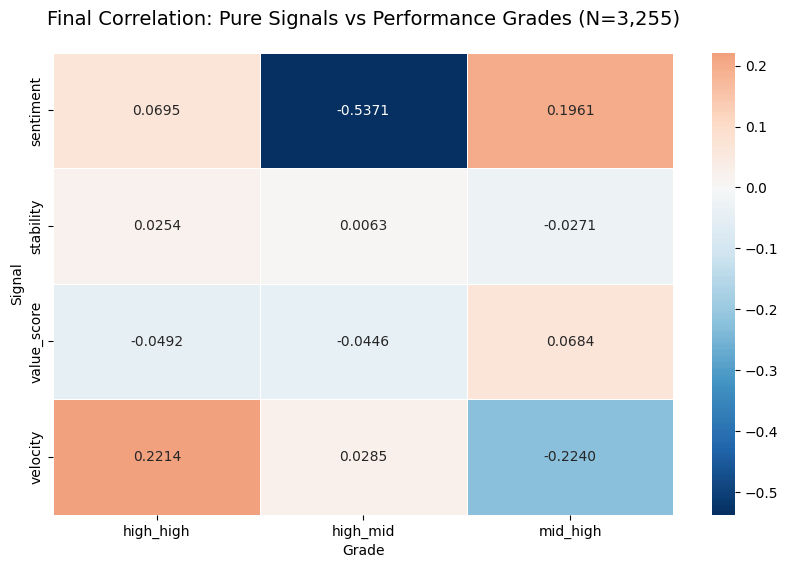

### [Step 1] Kruskal-Wallis Test (Final Definitions)
     Signal  H-Statistic  p-value
   velocity    2168.6519   0.0000
  sentiment     516.0975   0.0000
value_score      64.9109   0.0000
  stability       8.9309   0.0115

### [Step 2] Correlation Matrix
Grade        high_high  high_mid  mid_high
Signal                                    
sentiment       0.0695   -0.5371    0.1961
stability       0.0254    0.0063   -0.0271
value_score    -0.0492   -0.0446    0.0684
velocity        0.2214    0.0285   -0.2240


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, pearsonr

# 1. 데이터 로드 (지정된 경로 준수)
base_path = '../../../../data/preprocessed/'
df = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
hist_df = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

# -------------------------------------------------------------------
# 🎯 [Step 0] 최종 확정 4대 핵심 시그널 생성 (본 분석 정의 적용)
# -------------------------------------------------------------------

# [1] Stability (민심 안정도): 전체 기간 일별 긍정률의 표준편차
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / 
                            (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

# 데이터 결합
df = pd.merge(df, stability_stats, on='appid', how='left')

# [2] Velocity (누적 화제성): 전체 리뷰 총량
df['velocity'] = df['total_reviews']

# [3] Sentiment (평균 민심): 전체 긍정률
df['sentiment'] = df['positive_rate']

# [4] Value Score (심리적 가성비): 소유자 대비 추천 비율
# 심리적 만족도: 추천 수 / (소유자 수 + 1)
df['value_score'] = df['recommendations_total'].fillna(0) / (df['owners_lower'] + 1)

# 지표 정제
features = ['velocity', 'sentiment', 'value_score', 'stability']
df[features] = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

# 분석 대상 등급 필터링 (HH, HM, MH)
target_grades = ['high_high', 'high_mid', 'mid_high']
analysis_df = df[df['performance_grade'].isin(target_grades)].copy()

# -------------------------------------------------------------------
# 📊 [Step 1] Kruskal-Wallis Test (집단 간 유의미한 차이 검정)
# -------------------------------------------------------------------
kw_results = []
for f in features:
    groups = [analysis_df[analysis_df['performance_grade'] == g][f] for g in target_grades]
    stat, p = kruskal(*groups)
    kw_results.append({'Signal': f, 'H-Statistic': stat, 'p-value': p})
kw_df = pd.DataFrame(kw_results)

# -------------------------------------------------------------------
# 🔍 [Step 2] Correlation Analysis (성공 지문 확인)
# -------------------------------------------------------------------
corr_list = []
for grade in target_grades:
    target_col = f'is_{grade}'
    analysis_df[target_col] = (analysis_df['performance_grade'] == grade).astype(int)
    for f in features:
        r, p = pearsonr(analysis_df[f], analysis_df[target_col])
        corr_list.append({'Grade': grade, 'Signal': f, 'Correlation': r, 'p-value': p})

corr_df = pd.DataFrame(corr_list)
pivot_corr = corr_df.pivot(index='Signal', columns='Grade', values='Correlation')
pivot_corr = pivot_corr[['high_high', 'high_mid', 'mid_high']]

# -------------------------------------------------------------------
# 🎨 [Step 3] 시각화 (Correlation Heatmap)
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_corr, annot=True, cmap='RdBu_r', center=0, fmt='.4f', linewidths=0.5)
plt.title('Final Correlation: Pure Signals vs Performance Grades (N=3,255)', fontsize=14, pad=20)
plt.show()

# 결과 출력
print("### [Step 1] Kruskal-Wallis Test (Final Definitions)")
print(kw_df.to_string(index=False))
print("\n" + "="*80)
print("### [Step 2] Correlation Matrix")
print(pivot_corr.to_string())

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, pearsonr

# 1. 데이터 로드 (지정된 경로 준수)
base_path = '../../../../data/preprocessed/'
df = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
hist_df = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

# -------------------------------------------------------------------
# 🎯 [Step 0] 최종 확정 4대 핵심 시그널 생성 (본 분석 정의 적용)
# -------------------------------------------------------------------

# [1] Stability (민심 안정도): 전체 기간 일별 긍정률의 표준편차
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / 
                            (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

# 데이터 결합
df = pd.merge(df, stability_stats, on='appid', how='left')

# [2] Velocity (누적 화제성): 전체 리뷰 총량 (시장의 절대적 화력)
df['velocity'] = df['total_reviews']

# [3] Sentiment (평균 민심): 전체 긍정률 (순수 만족도)
df['sentiment'] = df['positive_rate']

# [4] Value Score (심리적 가성비): 소유자 대비 추천 비율 (구매 전환 효율)
df['value_score'] = df['recommendations_total'].fillna(0) / (df['owners_lower'] + 1)

# 지표 정제 (결측치 처리)
features = ['velocity', 'sentiment', 'value_score', 'stability']
df[features] = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

# 분석 대상 필터링 (HH, HM, MH)
target_grades = ['high_high', 'high_mid', 'mid_high']
analysis_df = df[df['performance_grade'].isin(target_grades)].copy()

# -------------------------------------------------------------------
# [함수] Hedges' g 계산 (집단 간 격차 측정용)
# -------------------------------------------------------------------
def get_hedges_g(g1, g2, col):
    n1, n2 = len(g1), len(g2)
    if n1 <= 1 or n2 <= 1: return 0
    m1, m2 = g1[col].mean(), g2[col].mean()
    v1, v2 = g1[col].var(), g2[col].var()
    # 합산 표준편차(Pooled Standard Deviation)
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    if pooled_std == 0: return 0
    # 작은 샘플 사이즈에 대한 보정 계수 포함
    return ((m1 - m2) / pooled_std) * (1 - (3 / (4 * (n1 + n2) - 9)))

# -------------------------------------------------------------------
# [실행] 통합 분석 파이프라인
# -------------------------------------------------------------------

# 1. Kruskal-Wallis (유의성 검정)
kw_results = []
for f in features:
    groups = [analysis_df[analysis_df['performance_grade'] == g][f] for g in target_grades]
    stat, p = kruskal(*groups)
    kw_results.append({'Signal': f, 'H-Stat': stat, 'p-value': p})

# 2. Correlation (등급별 연관성)
corr_list = []
for grade in target_grades:
    analysis_df[f'is_{grade}'] = (analysis_df['performance_grade'] == grade).astype(int)
    for f in features:
        r, _ = pearsonr(analysis_df[f], analysis_df[f'is_{grade}'])
        corr_list.append({'Grade': grade, 'Signal': f, 'Corr': r})

# 3. Hedges' g (실질적 격차 분석)
hh = analysis_df[analysis_df['performance_grade'] == 'high_high']
hm = analysis_df[analysis_df['performance_grade'] == 'high_mid']
mh = analysis_df[analysis_df['performance_grade'] == 'mid_high']

effect_list = []
for f in features:
    effect_list.append({
        'Signal': f,
        'HH vs HM': get_hedges_g(hh, hm, f),
        'HM vs MH': get_hedges_g(hm, mh, f),
        'Total(HH vs MH)': get_hedges_g(hh, mh, f)
    })

# 결과 출력
pd.options.display.float_format = '{:.4f}'.format
print("### [Step 1] Kruskal-Wallis (유의성 검정 - 최종 정의 적용)")
print(pd.DataFrame(kw_results).to_string(index=False))

print("\n" + "="*80)
print("### [Step 2] Correlation Matrix (상관관계)")
print(pd.DataFrame(corr_list).pivot(index='Signal', columns='Grade', values='Corr')[target_grades])

print("\n" + "="*80)
print("### [Step 3] Hedges' g (집단 간 실질 격차 = 효과 크기)")
print(pd.DataFrame(effect_list).to_string(index=False))

### [Step 1] Kruskal-Wallis (유의성 검정 - 최종 정의 적용)
     Signal    H-Stat  p-value
   velocity 2168.6519   0.0000
  sentiment  516.0975   0.0000
value_score   64.9109   0.0000
  stability    8.9309   0.0115

### [Step 2] Correlation Matrix (상관관계)
Grade        high_high  high_mid  mid_high
Signal                                    
sentiment       0.0695   -0.5371    0.1961
stability       0.0254    0.0063   -0.0271
value_score    -0.0492   -0.0446    0.0684
velocity        0.2214    0.0285   -0.2240

### [Step 3] Hedges' g (집단 간 실질 격차 = 효과 크기)
     Signal  HH vs HM  HM vs MH  Total(HH vs MH)
   velocity    0.1428    0.9515           0.5326
  sentiment    3.0518   -2.7397          -0.0296
value_score    0.0751   -0.3143          -0.1262
  stability    0.0145    0.0459           0.0604
